# 🗣️ NadiKampus: NLP Sentiment Analysis & Topic Extraction

Notebook ini memproses teks komentar dan keluhan mahasiswa (2.481 responden), menganalisis distribusi sentimen (Positif, Netral, Negatif), serta memetakan frekuensi topik permasalahan dominan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Baca data survei mahasiswa
df = pd.read_csv('../data/raw/data_survei_mahasiswa.csv')
print(f"Total komentar suara mahasiswa: {len(df):,}")
df[['student_id', 'topik_keluhan', 'sentimen']].head(10)

Total komentar suara mahasiswa: 2,481


,student_id,topik_keluhan,sentimen
0,MHS-00001,Layanan kampus dan fasilitas,Negatif
1,MHS-00002,Layanan kampus dan fasilitas,Negatif
2,MHS-00003,Kesepian dan adaptasi sosial,Negatif
3,MHS-00004,Kegiatan dan komunitas,Netral
4,MHS-00005,Kesepian dan adaptasi sosial,Negatif
5,MHS-00006,Layanan kampus dan fasilitas,Positif
6,MHS-00007,Kegiatan dan komunitas,Negatif
7,MHS-00008,Kecemasan karier dan magang,Negatif
8,MHS-00009,Beban tugas dan ujian,Positif
9,MHS-00010,Layanan kampus dan fasilitas,Positif


## 1. Distribusi Sentimen Suara Mahasiswa

In [2]:
sentiment_dist = df['sentimen'].value_counts(normalize=True) * 100
sentiment_dist.round(1)

sentimen
Negatif    48.8
Positif    29.1
Netral     22.1

### Visualisasi Grafik Sentimen (Donut Chart)

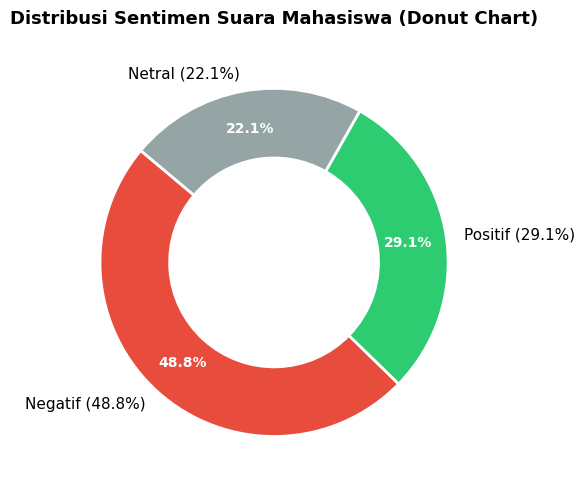

In [3]:
# Visualisasi Donut Chart Distribusi Sentimen
sentiment_counts = df['sentimen'].value_counts()
colors = {'Negatif': '#e74c3c', 'Positif': '#2ecc71', 'Netral': '#95a5a6'}
labels = [f"{k} ({sentiment_dist[k]:.1f}%)" for k in sentiment_counts.index]

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    sentiment_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=[colors.get(k, '#3498db') for k in sentiment_counts.index],
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
    pctdistance=0.78
)
plt.setp(autotexts, size=10, weight="bold", color="white")
plt.setp(texts, size=11)
ax.set_title('Distribusi Sentimen Suara Mahasiswa', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 2. Frekuensi Topik Permasalahan Dominan

In [4]:
topic_dist = df['topik_keluhan'].value_counts(normalize=True) * 100
topic_dist.round(1)

topik_keluhan
Kecemasan karier dan magang      15.2
Kesepian dan adaptasi sosial     14.8
Kegiatan dan komunitas           14.6
Beban tugas dan ujian            14.3
Layanan kampus dan fasilitas     14.0
Biaya kuliah dan keuangan        13.6
Dukungan dosen dan dosen wali    13.5